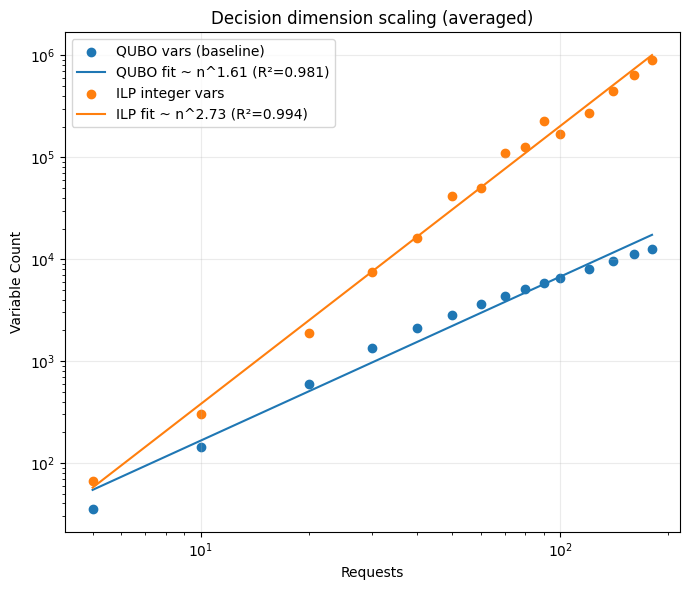

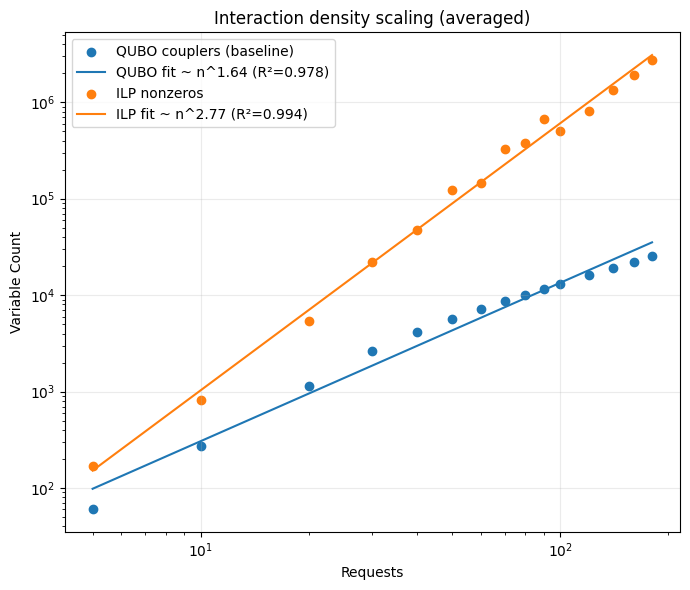


=== Decision dimension (averaged) ===
QUBO vars exponent: 1.609 (R²=0.981)
ILP integer vars exponent:2.729 (R²=0.994)

=== Interaction density (averaged) ===
QUBO couplers exponent: 1.642 (R²=0.978)
ILP nonzeros exponent: 2.768 (R²=0.994)


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

CSV_PATH = "results5-90.csv"
df = pd.read_csv(CSV_PATH)

# ----------------------------
# Clean / numeric conversion
# ----------------------------
df["run_type"] = df["run_type"].astype(str).str.strip()
for c in [
    "num_requests",
    "base_qubo_vars",
    "base_qubo_couplers",
    "ilp_num_integer_vars",
    "ilp_num_nonzero_coeffs",
]:
    df[c] = pd.to_numeric(df[c], errors="coerce")

d_class = df[df["run_type"] == "Classical"].copy()
d_quant = df[df["run_type"] == "Quantum"].copy()

def avg_by_requests(d, col):
    t = d[["num_requests", col]].dropna()
    return t.groupby("num_requests", as_index=False)[col].mean()

def fit_powerlaw(x, y):
    """Fit y ~ C * x^a via log10 regression. Return (a, C, r2)."""
    x = np.asarray(x, float)
    y = np.asarray(y, float)
    m = np.isfinite(x) & np.isfinite(y) & (x > 0) & (y > 0)
    x = x[m]
    y = y[m]
    lx = np.log10(x)
    ly = np.log10(y)
    a, b = np.polyfit(lx, ly, 1)  # ly = a*lx + b
    ly_hat = a * lx + b
    r2 = 1 - np.sum((ly - ly_hat) ** 2) / np.sum((ly - np.mean(ly)) ** 2)
    C = 10**b
    return a, C, r2


# ----------------------------
# Build averaged curves
# ----------------------------
qubo_vars = avg_by_requests(d_quant, "base_qubo_vars")
qubo_coup = avg_by_requests(d_quant, "base_qubo_couplers")
# IMPORTANT FIX: use integer vars since binary vars are 0 in your CSV
ilp_int = avg_by_requests(d_class, "ilp_num_integer_vars")
ilp_nnz = avg_by_requests(d_class, "ilp_num_nonzero_coeffs")

# ----------------------------
# Plot (separate images)
# ----------------------------

# Plot 1: QUBO vars vs ILP integer vars
plt.figure(figsize=(7, 6)) # Create a new figure
ax = plt.gca() # Get current axes
ax.set_title("Decision dimension scaling (averaged)")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Requests")
ax.set_ylabel("Variable Count")
ax.grid(alpha=0.25)
xq = qubo_vars["num_requests"].to_numpy()
yq = qubo_vars["base_qubo_vars"].to_numpy()
aq, Cq, r2q = fit_powerlaw(xq, yq)
ax.scatter(xq, yq, label="QUBO vars (baseline)")
xfit = np.logspace(np.log10(xq.min()), np.log10(xq.max()), 200)
ax.plot(xfit, Cq * (xfit**aq), label=f"QUBO fit ~ n^{aq:.2f} (R²={r2q:.3f})")

xi = ilp_int["num_requests"].to_numpy()
yi = ilp_int["ilp_num_integer_vars"].to_numpy()
ai, Ci, r2i = fit_powerlaw(xi, yi)
ax.scatter(xi, yi, label="ILP integer vars")
xfit = np.logspace(np.log10(xi.min()), np.log10(xi.max()), 200)
ax.plot(xfit, Ci * (xfit**ai), label=f"ILP fit ~ n^{ai:.2f} (R²={r2i:.3f})")
ax.legend()
plt.tight_layout()
plt.show()

# Plot 2: QUBO couplers vs ILP nonzeros
plt.figure(figsize=(7, 6)) # Create a new figure
ax = plt.gca() # Get current axes
ax.set_title("Interaction density scaling (averaged)")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Requests")
ax.set_ylabel("Variable Count")
ax.grid(alpha=0.25)
xq2 = qubo_coup["num_requests"].to_numpy()
yq2 = qubo_coup["base_qubo_couplers"].to_numpy()
aq2, Cq2, r2q2 = fit_powerlaw(xq2, yq2)
ax.scatter(xq2, yq2, label="QUBO couplers (baseline)")
xfit = np.logspace(np.log10(xq2.min()), np.log10(xq2.max()), 200)
ax.plot(xfit, Cq2 * (xfit**aq2), label=f"QUBO fit ~ n^{aq2:.2f} (R²={r2q2:.3f})")

xi2 = ilp_nnz["num_requests"].to_numpy()
yi2 = ilp_nnz["ilp_num_nonzero_coeffs"].to_numpy()
ai2, Ci2, r2i2 = fit_powerlaw(xi2, yi2)
ax.scatter(xi2, yi2, label="ILP nonzeros")
xfit = np.logspace(np.log10(xi2.min()), np.log10(xi2.max()), 200)
ax.plot(xfit, Ci2 * (xfit**ai2), label=f"ILP fit ~ n^{ai2:.2f} (R²={r2i2:.3f})")
ax.legend()
plt.tight_layout()
plt.show()

# ----------------------------
# Print numeric comparison
# ----------------------------
print("\n=== Decision dimension (averaged) ===")
print(f"QUBO vars exponent: {aq:.3f} (R²={r2q:.3f})")
print(f"ILP integer vars exponent:{ai:.3f} (R²={r2i:.3f})")
print("\n=== Interaction density (averaged) ===")
print(f"QUBO couplers exponent: {aq2:.3f} (R²={r2q2:.3f})")
print(f"ILP nonzeros exponent: {ai2:.3f} (R²={r2i2:.3f})")

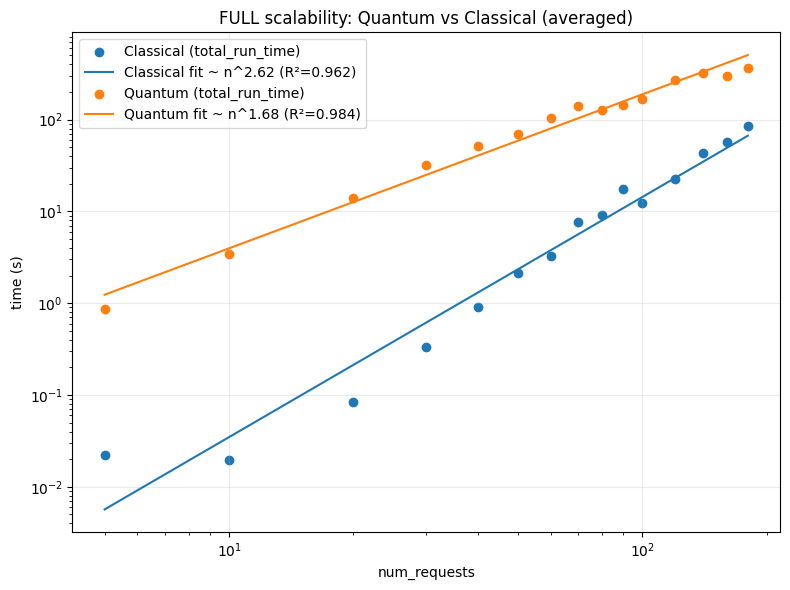


=== FULL runtime scaling (averaged) ===
Classical (total_run_time) exponent: 2.616 (R²=0.962)
Quantum   (total_run_time) exponent: 1.677 (R²=0.984)
Exponent difference (Quantum - Classical): -0.938


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

CSV_PATH = "results5-90.csv"
df = pd.read_csv(CSV_PATH)

# ----------------------------
# Clean / numeric conversion
# ----------------------------
df["run_type"] = df["run_type"].astype(str).str.strip()

# Convert likely timing columns if present
maybe_numeric = [
    "num_requests",
    "total_run_time",
    "solve_time",
    "ilp_run_time",
    "rtv_graph_build_time",
    "qubo_build_time",
    "time_min_cost_prep",
    "time_qubo_gen",
    "time_compress",
    "time_quantum_solve",
    "time_decode",
    "time_vehicle_assignment",
    "time_metrics_calc",
    "time_struct_stats",
    "time_total_quantum_block",
]
for c in maybe_numeric:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

d_class = df[df["run_type"] == "Classical"].copy()
d_quant = df[df["run_type"] == "Quantum"].copy()

def avg_by_requests(d, col):
    t = d[["num_requests", col]].dropna()
    return t.groupby("num_requests", as_index=False)[col].mean()

def fit_powerlaw(x, y):
    """Fit y ~ C * x^a via log10 regression. Return (a, C, r2)."""
    x = np.asarray(x, float)
    y = np.asarray(y, float)
    m = np.isfinite(x) & np.isfinite(y) & (x > 0) & (y > 0)
    x = x[m]
    y = y[m]
    lx = np.log10(x)
    ly = np.log10(y)
    a, b = np.polyfit(lx, ly, 1)  # ly = a*lx + b
    ly_hat = a * lx + b
    r2 = 1 - np.sum((ly - ly_hat) ** 2) / np.sum((ly - np.mean(ly)) ** 2)
    C = 10**b
    return a, C, r2

def first_present(cols):
    for c in cols:
        if c in df.columns:
            return c
    return None

# ----------------------------
# Define "FULL" times
# ----------------------------
# Classical full time: prefer total_run_time, else fall back to solve_time
class_full_col = first_present(["total_run_time", "solve_time"])
if class_full_col is None:
    raise ValueError("Need a classical total time column: total_run_time or solve_time")

# Quantum full time: prefer total_run_time, else compose a full pipeline sum
quant_full_col = first_present(["total_run_time", "solve_time"])
use_composed_quantum = False

if quant_full_col is None or d_quant[quant_full_col].dropna().empty:
    use_composed_quantum = True

if use_composed_quantum:
    # Compose a full quantum pipeline time from parts that exist.
    # You can add/remove components here based on what you define as "FULL".
    components = [
        "rtv_graph_build_time",
        "time_min_cost_prep",
        "time_qubo_gen",
        "qubo_build_time",
        "time_quantum_solve",
        "time_decode",
        "time_vehicle_assignment",
        "time_metrics_calc",
        "time_struct_stats",
    ]
    present = [c for c in components if c in df.columns]
    if len(present) == 0:
        raise ValueError("Cannot compose quantum full time: none of the expected component columns exist.")

    d_quant["full_quantum_time"] = 0.0
    for c in present:
        d_quant["full_quantum_time"] += d_quant[c].fillna(0.0)

    quant_full_col = "full_quantum_time"
    print("Using composed Quantum full time from:", present)

# ----------------------------
# Build averaged curves
# ----------------------------
class_curve = avg_by_requests(d_class, class_full_col)
quant_curve = avg_by_requests(d_quant, quant_full_col)

# ----------------------------
# Fit power laws
# ----------------------------
xc = class_curve["num_requests"].to_numpy()
yc = class_curve[class_full_col].to_numpy()
ac, Cc, r2c = fit_powerlaw(xc, yc)

xq = quant_curve["num_requests"].to_numpy()
yq = quant_curve[quant_full_col].to_numpy()
aq, Cq, r2q = fit_powerlaw(xq, yq)

# ----------------------------
# Plot: log-log comparison
# ----------------------------
plt.figure(figsize=(8, 6))
plt.title("FULL scalability: Quantum vs Classical (averaged)")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("num_requests")
plt.ylabel("time (s)")
plt.grid(alpha=0.25)

plt.scatter(xc, yc, label=f"Classical ({class_full_col})")
xfit = np.logspace(np.log10(xc.min()), np.log10(xc.max()), 200)
plt.plot(xfit, Cc * (xfit**ac), label=f"Classical fit ~ n^{ac:.2f} (R²={r2c:.3f})")

plt.scatter(xq, yq, label=f"Quantum ({quant_full_col})")
xfit = np.logspace(np.log10(xq.min()), np.log10(xq.max()), 200)
plt.plot(xfit, Cq * (xfit**aq), label=f"Quantum fit ~ n^{aq:.2f} (R²={r2q:.3f})")

plt.legend()
plt.tight_layout()
plt.show()

print("\n=== FULL runtime scaling (averaged) ===")
print(f"Classical ({class_full_col}) exponent: {ac:.3f} (R²={r2c:.3f})")
print(f"Quantum   ({quant_full_col}) exponent: {aq:.3f} (R²={r2q:.3f})")
print(f"Exponent difference (Quantum - Classical): {(aq - ac):.3f}")

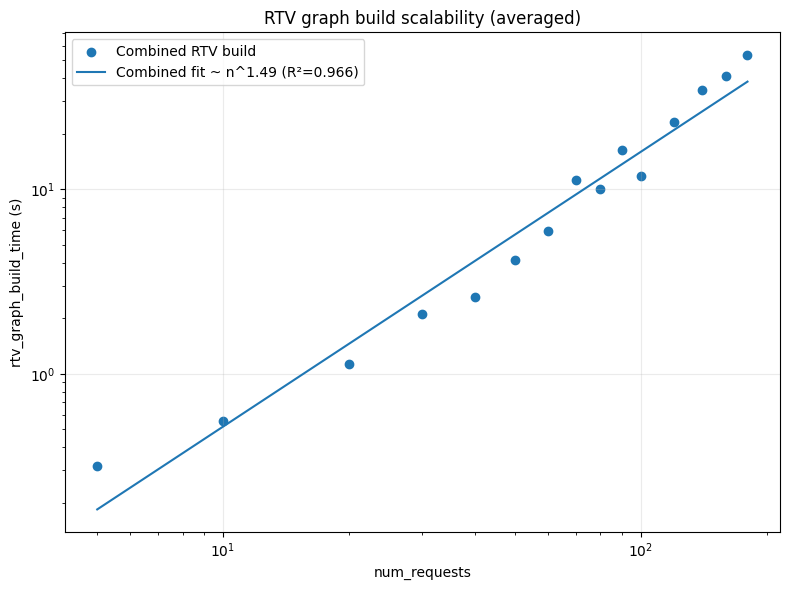


=== RTV graph build (averaged) ===
Combined exponent: 1.489 (R²=0.966)


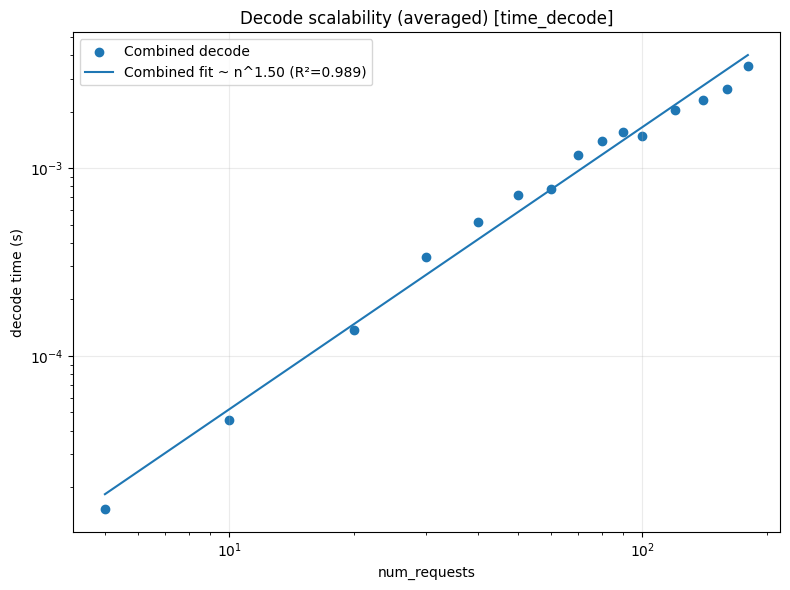

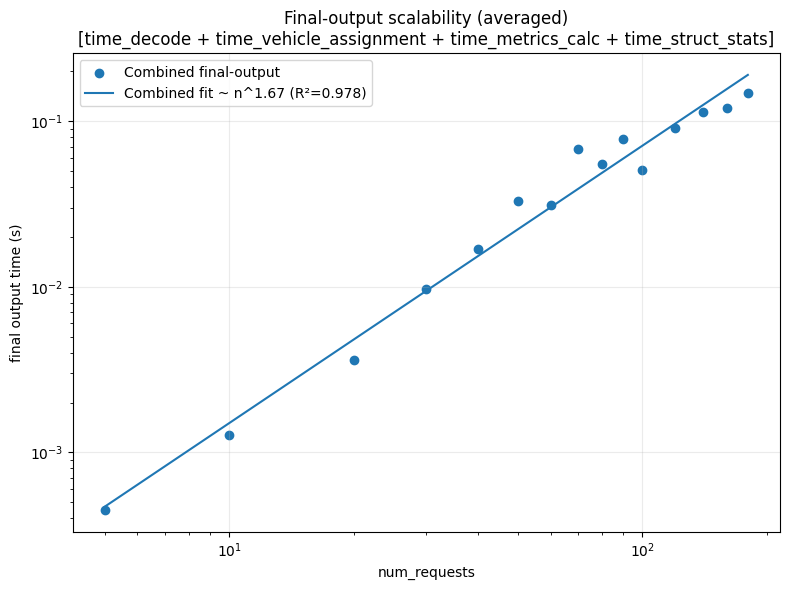


=== Decode only (averaged) ===
Combined exponent: 1.504 (R²=0.989)

=== Final output (averaged) ===
Combined exponent: 1.674 (R²=0.978)


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

CSV_PATH = "results5-90.csv"
df = pd.read_csv(CSV_PATH)

# ----------------------------
# Clean / numeric conversion
# ----------------------------
df["run_type"] = df["run_type"].astype(str).str.strip()

# Core x-axis
df["num_requests"] = pd.to_numeric(df["num_requests"], errors="coerce")

# Columns we may use (convert if present)
maybe_numeric = [
    # RTV
    "rtv_graph_build_time",

    # Decode / final output (common)
    "time_decode",
    "time_vehicle_assignment",
    "time_metrics_calc",
    "time_struct_stats",

    # Fallbacks / alternates seen in some CSVs
    "decode_time",
    "vehicle_assignment_time",
    "metrics_calc_time",
    "struct_stats_time",

    # If you also want overall runtime comparisons (optional)
    "total_run_time",
]
for c in maybe_numeric:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

# No longer separating into d_class and d_quant as per user request
# d_class = df[df["run_type"] == "Classical"].copy()
# d_quant = df[df["run_type"] == "Quantum"].copy()

def avg_by_requests(d, col):
    t = d[["num_requests", col]].dropna()
    return t.groupby("num_requests", as_index=False)[col].mean()

def fit_powerlaw(x, y):
    """Fit y ~ C * x^a via log10 regression. Return (a, C, r2)."""
    x = np.asarray(x, float)
    y = np.asarray(y, float)
    m = np.isfinite(x) & np.isfinite(y) & (x > 0) & (y > 0)
    x = x[m]
    y = y[m]
    # Check if x or y is empty after masking
    if len(x) == 0 or len(y) == 0:
        return np.nan, np.nan, np.nan # Return NaNs if no valid data points

    lx = np.log10(x)
    ly = np.log10(y)
    a, b = np.polyfit(lx, ly, 1)  # ly = a*lx + b
    ly_hat = a * lx + b
    r2 = 1 - np.sum((ly - ly_hat) ** 2) / np.sum((ly - np.mean(ly)) ** 2)
    C = 10 ** b
    return a, C, r2

def first_present(cols):
    for c in cols:
        if c in df.columns:
            return c
    return None

# ============================================================
# RTV Graph build scalability (Combined data)
# ============================================================
if "rtv_graph_build_time" not in df.columns:
    raise ValueError("CSV missing required column: rtv_graph_build_time")

rtv_avg_data = avg_by_requests(df, "rtv_graph_build_time")

plt.figure(figsize=(8, 6))
plt.title("RTV graph build scalability (averaged)")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("num_requests")
plt.ylabel("rtv_graph_build_time (s)")
plt.grid(alpha=0.25)

x = rtv_avg_data["num_requests"].to_numpy()
y = rtv_avg_data["rtv_graph_build_time"].to_numpy()
if len(x) > 0:
    a, C, r2 = fit_powerlaw(x, y)
    plt.scatter(x, y, label="Combined RTV build")
    xfit = np.logspace(np.log10(x.min()), np.log10(x.max()), 200)
    plt.plot(xfit, C * (xfit ** a), label=f"Combined fit ~ n^{a:.2f} (R²={r2:.3f})")
else:
    a, C, r2 = np.nan, np.nan, np.nan
    print("Warning: No data for Combined RTV build scalability.")

plt.legend()
plt.tight_layout()
plt.show()

print("\n=== RTV graph build (averaged) ===")
print(f"Combined exponent: {a:.3f} (R²={r2:.3f})")

# ============================================================
# Decode + final output scalability (Combined data)
# ============================================================
# We compute:
#   decode_only = time_decode (or decode_time)
#   final_output = decode_only + vehicle_assignment + metrics_calc + struct_stats
#
# If any component column is missing, it is treated as 0 for final_output,
# EXCEPT decode_only (if decode missing, we error because your request is "decode").
decode_col = first_present(["time_decode", "decode_time"])
va_col     = first_present(["time_vehicle_assignment", "vehicle_assignment_time"])
mc_col     = first_present(["time_metrics_calc", "metrics_calc_time"])
ss_col     = first_present(["time_struct_stats", "struct_stats_time"])

if decode_col is None:
    raise ValueError("CSV missing decode column: expected one of [time_decode, decode_time]")

# Build per-row totals directly on df (so averaging is consistent)
df["decode_only"] = df[decode_col]
df["final_output_time"] = (
    df[decode_col].fillna(0.0)
    + (df[va_col].fillna(0.0) if va_col is not None else 0.0)
    + (df[mc_col].fillna(0.0) if mc_col is not None else 0.0)
    + (df[ss_col].fillna(0.0) if ss_col is not None else 0.0)
)

decode_avg_data = avg_by_requests(df, "decode_only")
final_avg_data  = avg_by_requests(df, "final_output_time")

# Panel 1: Decode only
plt.figure(figsize=(8, 6)) # Create a new figure for this plot
ax = plt.gca() # Get current axes
ax.set_title(f"Decode scalability (averaged) [{decode_col}]")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("num_requests")
ax.set_ylabel("decode time (s)")
ax.grid(alpha=0.25)

x = decode_avg_data["num_requests"].to_numpy()
y = decode_avg_data["decode_only"].to_numpy()
if len(x) > 0:
    a_decode, C_decode, r2_decode = fit_powerlaw(x, y)
    ax.scatter(x, y, label="Combined decode")
    xfit = np.logspace(np.log10(x.min()), np.log10(x.max()), 200)
    ax.plot(xfit, C_decode * (xfit ** a_decode), label=f"Combined fit ~ n^{a_decode:.2f} (R²={r2_decode:.3f})")
else:
    a_decode, C_decode, r2_decode = np.nan, np.nan, np.nan
    print("Warning: No data for Combined decode scalability.")
ax.legend()
plt.tight_layout()
plt.show()

# Panel 2: Final output (decode + assignment + metrics + stats)
components = [decode_col] + [c for c in [va_col, mc_col, ss_col] if c is not None]
plt.figure(figsize=(8, 6)) # Create another new figure for this plot
ax = plt.gca() # Get current axes
ax.set_title("Final-output scalability (averaged)\n[" + " + ".join(components) + "]")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("num_requests")
ax.set_ylabel("final output time (s)")
ax.grid(alpha=0.25)

x = final_avg_data["num_requests"].to_numpy()
y = final_avg_data["final_output_time"].to_numpy()
if len(x) > 0:
    a_final, C_final, r2_final = fit_powerlaw(x, y)
    ax.scatter(x, y, label="Combined final-output")
    xfit = np.logspace(np.log10(x.min()), np.log10(x.max()), 200)
    ax.plot(xfit, C_final * (xfit ** a_final), label=f"Combined fit ~ n^{a_final:.2f} (R²={r2_final:.3f})")
else:
    a_final, C_final, r2_final = np.nan, np.nan, np.nan
    print("Warning: No data for Combined final-output scalability.")
ax.legend()
plt.tight_layout()
plt.show()

print("\n=== Decode only (averaged) ===")
print(f"Combined exponent: {a_decode:.3f} (R²={r2_decode:.3f})")

print("\n=== Final output (averaged) ===")
print(f"Combined exponent: {a_final:.3f} (R²={r2_final:.3f})")

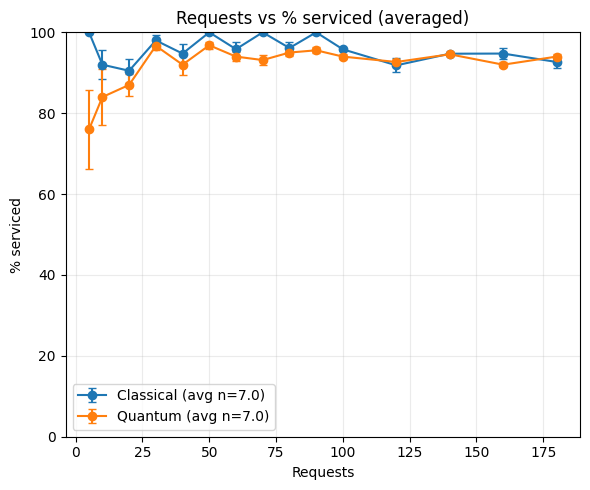

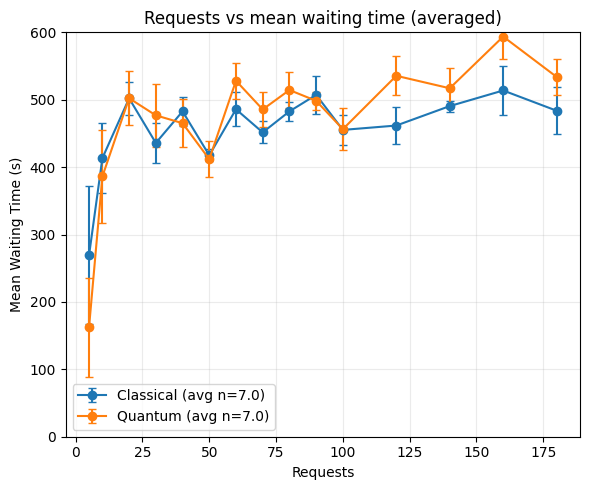

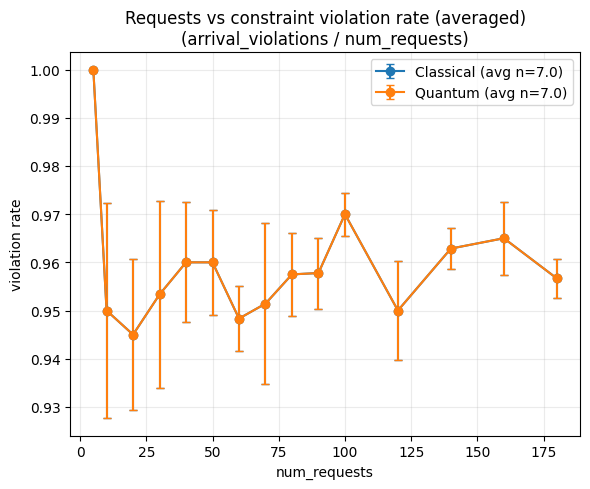

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

CSV_PATH = "results5-90.csv"
df = pd.read_csv(CSV_PATH)

# ----------------------------
# Clean / numeric conversion
# ----------------------------
df["run_type"] = df["run_type"].astype(str).str.strip()

# X + common Y columns
for c in ["num_requests", "percent_serviced", "avg_waiting_time", "arrival_violations", "infeasible_windows"]:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

d_class = df[df["run_type"] == "Classical"].copy()
d_quant = df[df["run_type"] == "Quantum"].copy()

def avg_by_requests(d, col):
    t = d[["num_requests", col]].dropna()
    # Return mean, standard error of the mean (sem), and count
    grouped = t.groupby("num_requests")[col].agg(['mean', 'sem', 'count'])
    grouped = grouped.reset_index()
    grouped.columns = ['num_requests', col + '_mean', col + '_sem', col + '_count']
    return grouped

def pick_col(candidates):
    for c in candidates:
        if c in df.columns:
            return c
    raise ValueError(f"None of these columns exist in the CSV: {candidates}")

# ----------------------------
# Choose columns robustly
# ----------------------------
col_ps = pick_col(["percent_serviced", "% Serviced Requests", "pct_serviced", "service_rate"])
col_wait = pick_col(["avg_waiting_time", "mean_waiting_time", "average_waiting_time"])

# Constraint violation rate:
# Prefer arrival_violations / num_requests if present.
# Else, fallback to infeasible_windows / num_requests.
viol_num = None
viol_kind = None
if "arrival_violations" in df.columns:
    viol_num, viol_kind = "arrival_violations", "arrival_violations / num_requests"
elif "infeasible_windows" in df.columns:
    viol_num, viol_kind = "infeasible_windows", "infeasible_windows / num_requests"
else:
    raise ValueError("No constraint-violation column found. Need one of: arrival_violations, infeasible_windows")

# Build per-row violation rate, then average by requests (this avoids bias if you average numerator first)
for d in (d_class, d_quant):
    d["violation_rate"] = d[viol_num] / d["num_requests"]

# ----------------------------
# Build averaged curves with SEM and count
# ----------------------------
ps_class_data = avg_by_requests(d_class, col_ps)
ps_quant_data = avg_by_requests(d_quant, col_ps)

wait_class_data = avg_by_requests(d_class, col_wait)
wait_quant_data = avg_by_requests(d_quant, col_wait)

viol_class_data = avg_by_requests(d_class, "violation_rate")
viol_quant_data = avg_by_requests(d_quant, "violation_rate")

# ----------------------------
# Plot: 3 panels (separate images)
# ----------------------------

# Plot 1: percent serviced
plt.figure(figsize=(6, 5)) # Create a new figure
ax = plt.gca() # Get current axes
ax.set_ylim(bottom=0, top=100)
ax.set_title("Requests vs % serviced (averaged)")
ax.set_xlabel("Requests")
ax.set_ylabel("% serviced")
ax.grid(alpha=0.25)
ax.errorbar(ps_class_data["num_requests"], ps_class_data[col_ps + "_mean"], yerr=ps_class_data[col_ps + "_sem"], fmt='-o', capsize=3, label=f"Classical (avg n={ps_class_data[col_ps + '_count'].mean():.1f})")
ax.errorbar(ps_quant_data["num_requests"], ps_quant_data[col_ps + "_mean"], yerr=ps_quant_data[col_ps + "_sem"], fmt='-o', capsize=3, label=f"Quantum (avg n={ps_quant_data[col_ps + '_count'].mean():.1f})")
ax.legend()
plt.tight_layout()
plt.show()

# Plot 2: mean waiting time
plt.figure(figsize=(6, 5)) # Create a new figure
ax = plt.gca() # Get current axes
ax.set_ylim(bottom=0, top=600)
ax.set_title("Requests vs mean waiting time (averaged)")
ax.set_xlabel("Requests")
ax.set_ylabel("Mean Waiting Time (s)")
ax.grid(alpha=0.25)
ax.errorbar(wait_class_data["num_requests"], wait_class_data[col_wait + "_mean"], yerr=wait_class_data[col_wait + "_sem"], fmt='-o', capsize=3, label=f"Classical (avg n={wait_class_data[col_wait + '_count'].mean():.1f})")
ax.errorbar(wait_quant_data["num_requests"], wait_quant_data[col_wait + "_mean"], yerr=wait_quant_data[col_wait + "_sem"], fmt='-o', capsize=3, label=f"Quantum (avg n={wait_quant_data[col_wait + '_count'].mean():.1f})")
ax.legend()
plt.tight_layout()
plt.show()

# Plot 3: constraint violation rate
plt.figure(figsize=(6, 5)) # Create a new figure
ax = plt.gca() # Get current axes
ax.set_title(f"Requests vs constraint violation rate (averaged)\n({viol_kind})")
ax.set_xlabel("num_requests")
ax.set_ylabel("violation rate")
ax.grid(alpha=0.25)
ax.errorbar(viol_class_data["num_requests"], viol_class_data["violation_rate_mean"], yerr=viol_class_data["violation_rate_sem"], fmt='-o', capsize=3, label=f"Classical (avg n={viol_class_data['violation_rate_count'].mean():.1f})")
ax.errorbar(viol_quant_data["num_requests"], viol_quant_data["violation_rate_mean"], yerr=viol_quant_data["violation_rate_sem"], fmt='-o', capsize=3, label=f"Quantum (avg n={viol_quant_data['violation_rate_count'].mean():.1f})")
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np
from scipy import stats

CSV_PATH = "results5-90.csv"
df = pd.read_csv(CSV_PATH)

df["run_type"] = df["run_type"].astype(str).str.strip()

# Convert numeric columns
for c in [
    "num_requests",
    "percent_serviced",
    "avg_waiting_time",
    "arrival_violations",
]:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

# Build violation rate if possible
if "arrival_violations" in df.columns:
    df["violation_rate"] = df["arrival_violations"] / df["num_requests"]

# ---------------------------------------------------------
# IMPORTANT: define columns that uniquely identify instance
# ---------------------------------------------------------
# Adjust if necessary
instance_cols = ["city", "num_requests", "seed", "trial"]
instance_cols = [c for c in instance_cols if c in df.columns]

if len(instance_cols) == 0:
    raise ValueError("No instance-identifying columns found. Add city/seed/trial.")

# Split algorithms
d_class = df[df["run_type"] == "Classical"].copy()
d_quant = df[df["run_type"] == "Quantum"].copy()

def paired_test(metric_name):
    print("\n" + "="*60)
    print(f"Metric: {metric_name}")
    print("="*60)

    # Merge on identical instances
    merged = pd.merge(
        d_class[instance_cols + [metric_name]],
        d_quant[instance_cols + [metric_name]],
        on=instance_cols,
        suffixes=("_class", "_quant")
    ).dropna()

    if len(merged) < 5:
        print("Not enough paired samples.")
        return

    x = merged[f"{metric_name}_class"].values
    y = merged[f"{metric_name}_quant"].values
    diff = y - x

    # Paired t-test
    t_stat, p_val = stats.ttest_rel(y, x)

    # Wilcoxon (nonparametric)
    try:
        w_stat, p_w = stats.wilcoxon(diff)
    except:
        p_w = np.nan

    # Effect size (Cohen's d for paired)
    d_cohen = np.mean(diff) / np.std(diff, ddof=1)

    # 95% CI
    ci = stats.t.interval(
        0.95,
        len(diff)-1,
        loc=np.mean(diff),
        scale=stats.sem(diff)
    )

    print(f"Samples: {len(diff)}")
    print(f"Mean difference (Quantum - Classical): {np.mean(diff):.4f}")
    print(f"Paired t-test p-value: {p_val:.6g}")
    print(f"Wilcoxon p-value: {p_w:.6g}")
    print(f"Cohen's d: {d_cohen:.3f}")
    print(f"95% CI of difference: {ci}")

# ---------------------------------------------------------
# Run tests
# ---------------------------------------------------------
paired_test("percent_serviced")
paired_test("avg_waiting_time")
paired_test("violation_rate")


Metric: percent_serviced
Samples: 105
Mean difference (Quantum - Classical): -3.7196
Paired t-test p-value: 4.97935e-05
Wilcoxon p-value: 5.6205e-07
Cohen's d: -0.413
95% CI of difference: (np.float64(-5.461956580726413), np.float64(-1.9771968584270274))

Metric: avg_waiting_time
Samples: 105
Mean difference (Quantum - Classical): 13.5648
Paired t-test p-value: 0.182967
Wilcoxon p-value: 0.0800746
Cohen's d: 0.131
95% CI of difference: (np.float64(-6.500304535756767), np.float64(33.63000383871573))

Metric: violation_rate
Samples: 105
Mean difference (Quantum - Classical): 0.0000
Paired t-test p-value: nan
Wilcoxon p-value: nan
Cohen's d: nan
95% CI of difference: (np.float64(nan), np.float64(nan))


/usr/local/lib/python3.12/dist-packages/scipy/stats/_wilcoxon.py:178: RuntimeWarning: invalid value encountered in scalar divide
  z = (r_plus - mn) / se
/tmp/ipykernel_1775/4216261348.py:69: RuntimeWarning: invalid value encountered in scalar divide
  d_cohen = np.mean(diff) / np.std(diff, ddof=1)
/usr/local/lib/python3.12/dist-packages/scipy/stats/_distn_infrastructure.py:2323: RuntimeWarning: invalid value encountered in multiply
  lower_bound = _a * scale + loc
/usr/local/lib/python3.12/dist-packages/scipy/stats/_distn_infrastructure.py:2324: RuntimeWarning: invalid value encountered in multiply
  upper_bound = _b * scale + loc


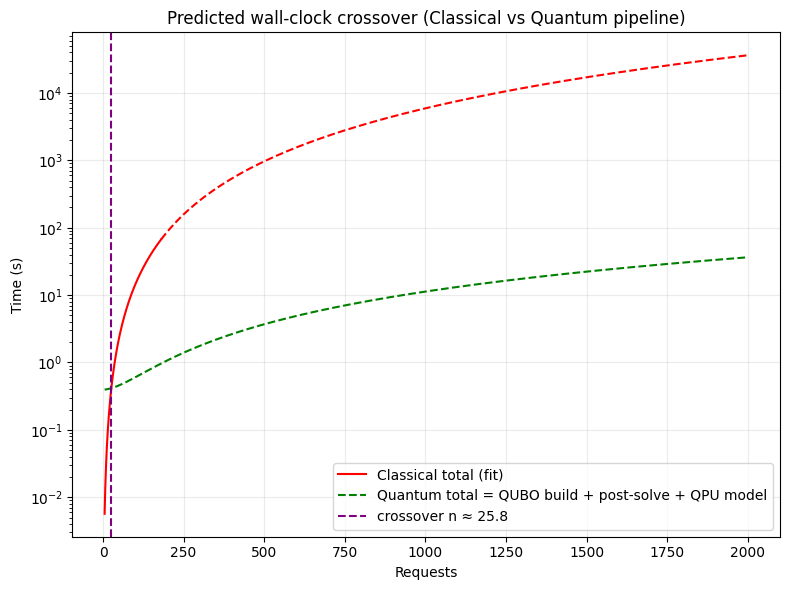


=== Fits ===
Classical total time ~ n^2.616 (R²=0.962)
QUBO build time       ~ n^1.805 (R²=0.993)
Post-solve time       ~ n^1.674 (R²=0.978)

=== Crossover ===
Predicted crossover at n ≈ 25.8 requests (under your QPU timing assumptions).


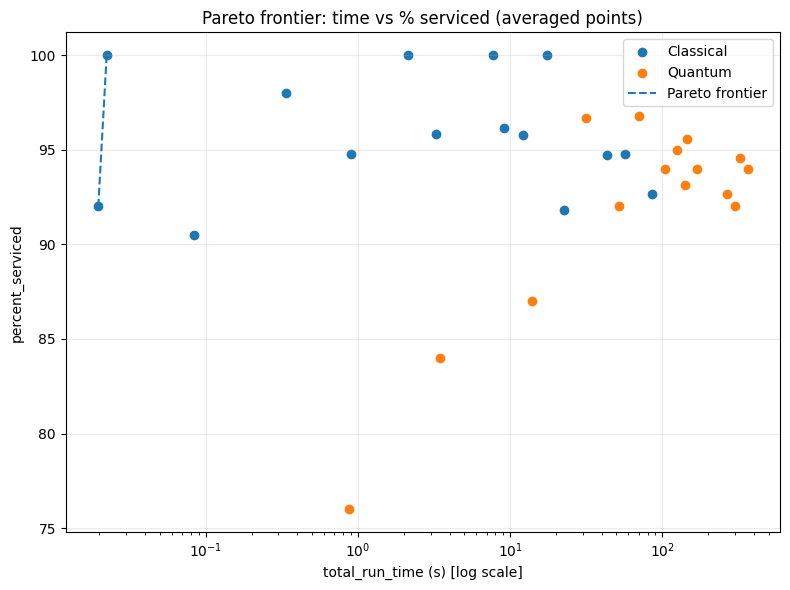

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

CSV_PATH = "results5-90.csv"
df = pd.read_csv(CSV_PATH)

# ----------------------------
# Clean / numeric conversion
# ----------------------------
df["run_type"] = df["run_type"].astype(str).str.strip()

# Columns we will use (convert if present)
for c in [
    "num_requests",
    "total_run_time",
    "qubo_build_time",
    "time_decode",
    "time_vehicle_assignment",
    "time_metrics_calc",
    "time_struct_stats",
    "percent_serviced",
]:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

# Required for this analysis
required = ["num_requests", "run_type", "total_run_time"]
missing = [c for c in required if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

# Filter to the two algorithms for crossover
d_class = df[df["run_type"] == "Classical"].copy()
d_quant = df[df["run_type"] == "Quantum"].copy()

# ----------------------------
# Helpers
# ----------------------------
def avg_by_requests(d, col):
    t = d[["num_requests", col]].dropna()
    return t.groupby("num_requests", as_index=False)[col].mean()

def fit_powerlaw(x, y):
    """
    Fit y ~ C * x^a via log10 regression.
    Returns (a, C, r2) and a predictor f(n).
    """
    x = np.asarray(x, float)
    y = np.asarray(y, float)
    m = np.isfinite(x) & np.isfinite(y) & (x > 0) & (y > 0)
    x = x[m]
    y = y[m]
    lx = np.log10(x)
    ly = np.log10(y)
    a, b = np.polyfit(lx, ly, 1)  # ly = a*lx + b
    ly_hat = a * lx + b
    r2 = 1 - np.sum((ly - ly_hat) ** 2) / np.sum((ly - np.mean(ly)) ** 2)
    C = 10**b

    def f(n):
        n = np.asarray(n, float)
        return C * (n**a)

    return a, C, r2, f

def first_present(cols):
    for c in cols:
        if c in df.columns:
            return c
    return None

# ----------------------------
# Define "quantum pipeline time" from your CSV components
# ----------------------------
# These are on your side (CPU-side) and DO scale with n:
qubo_col = "qubo_build_time" if "qubo_build_time" in df.columns else None

decode_col = first_present(["time_decode", "decode_time"])
va_col     = first_present(["time_vehicle_assignment", "vehicle_assignment_time"])
mc_col     = first_present(["time_metrics_calc", "metrics_calc_time"])
ss_col     = first_present(["time_struct_stats", "struct_stats_time"])

if qubo_col is None:
    raise ValueError("Need qubo_build_time in CSV to model quantum pipeline time.")

if decode_col is None:
    # It's okay to set decode to 0 if you truly don't have it,
    # but you asked for decode earlier, so error to avoid silent nonsense.
    raise ValueError("Need a decode column: time_decode or decode_time.")

# Build per-row post-solve time (decode + assignment + metrics + stats)
for d in [d_quant]:
    d["post_solve_time"] = (
        d[decode_col].fillna(0.0)
        + (d[va_col].fillna(0.0) if va_col is not None else 0.0)
        + (d[mc_col].fillna(0.0) if mc_col is not None else 0.0)
        + (d[ss_col].fillna(0.0) if ss_col is not None else 0.0)
    )

# ----------------------------
# Fit classical total time vs n
# ----------------------------
class_tot = avg_by_requests(d_class, "total_run_time")
xc = class_tot["num_requests"].to_numpy()
yc = class_tot["total_run_time"].to_numpy()
aC, CC, r2C, f_class_total = fit_powerlaw(xc, yc)

# ----------------------------
# Fit quantum CPU-side parts vs n: QUBO build + post-solve
# ----------------------------
q_qubo = avg_by_requests(d_quant, qubo_col)
xq1 = q_qubo["num_requests"].to_numpy()
yq1 = q_qubo[qubo_col].to_numpy()
aQb, CQb, r2Qb, f_qubo = fit_powerlaw(xq1, yq1)

q_post = avg_by_requests(d_quant, "post_solve_time")
xq2 = q_post["num_requests"].to_numpy()
yq2 = q_post["post_solve_time"].to_numpy()
aQp, CQp, r2Qp, f_post = fit_powerlaw(xq2, yq2)

# ----------------------------
# "Current quantum computing time" model (D-Wave-like annealing)
# ----------------------------
def dwave_qpu_time_seconds(
    num_reads=2000,
    anneal_us=50,            # example used in published D-Wave experiments; set to your actual.
    readout_us=120,          # hardware-specific; keep param
    qpu_delay_us=20,         # hardware-specific; keep param
    programming_ms=10,       # per-problem programming/overhead; keep param
    other_overhead_ms=5,     # per-problem fixed overhead; keep param
    queue_overhead_s=0.0     # wall-clock queueing (Braket/Leap); can dominate.
):
    """
    QPU sampling time is broken into per-sample components (anneal + readout + delay)
    plus per-problem overhead/programming.
    """
    per_sample_us = anneal_us + readout_us + qpu_delay_us
    sampling_s = (num_reads * per_sample_us) * 1e-6
    fixed_s = (programming_ms + other_overhead_ms) * 1e-3
    return queue_overhead_s + fixed_s + sampling_s

# ----------------------------
# Total predicted times
# ----------------------------
def pred_classical_total(n):
    return f_class_total(n)

def pred_quantum_total(n, qpu_kwargs=None):
    if qpu_kwargs is None:
        qpu_kwargs = {}
    return f_qubo(n) + f_post(n) + dwave_qpu_time_seconds(**qpu_kwargs)

# ----------------------------
# Find crossover n where quantum < classical
# ----------------------------
def find_crossover(n_min=5, n_max=2000, grid=5000, qpu_kwargs=None):
    ns = np.linspace(n_min, n_max, grid)
    tc = pred_classical_total(ns)
    tq = pred_quantum_total(ns, qpu_kwargs=qpu_kwargs)
    diff = tq - tc

    # Find first sign change (quantum becomes faster)
    idx = np.where(np.sign(diff[:-1]) != np.sign(diff[1:]))[0]
    if len(idx) == 0:
        return None, ns, tc, tq
    i = idx[0]
    # linear interp
    n0, n1 = ns[i], ns[i+1]
    d0, d1 = diff[i], diff[i+1]
    n_star = n0 - d0 * (n1 - n0) / (d1 - d0)
    return float(n_star), ns, tc, tq

# Example hardware setting (EDIT THIS):
# - anneal_us=50 comes from a published D-Wave experiment setup
# - queue_overhead_s is 0 here; on real cloud it can dominate
qpu_example = dict(
    num_reads=2000,
    anneal_us=50,
    readout_us=120,
    qpu_delay_us=20,
    programming_ms=10,
    other_overhead_ms=5,
    queue_overhead_s=0.0
)

n_star, ns, tc, tq = find_crossover(n_min=max(5, min(xc.min(), xq1.min())), n_max=2000, grid=6000, qpu_kwargs=qpu_example)

plt.figure(figsize=(8,6))
plt.title("Predicted wall-clock crossover (Classical vs Quantum pipeline)")

# Classical total line: solid for measured range, dashed for predicted range
measured_max_n = xc.max()
idx_measured = ns <= measured_max_n
idx_predicted = ns > measured_max_n

plt.plot(ns[idx_measured], tc[idx_measured], label="Classical total (fit)", color='red', linestyle='-')
plt.plot(ns[idx_predicted], tc[idx_predicted], label="_Classical total (fit) [predicted]", color='red', linestyle='--') # Use _ to hide from legend

# Quantum total line: all dashed
plt.plot(ns, tq, label="Quantum total = QUBO build + post-solve + QPU model", color='green', linestyle='--')

# Crossover line: dashed and different color
if n_star is not None:
    plt.axvline(n_star, linestyle="--", color='purple', label=f"crossover n \u2248 {n_star:.1f}")
plt.xlabel("Requests")
plt.ylabel("Time (s)")
plt.yscale("log")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

print("\n=== Fits ===")
print(f"Classical total time ~ n^{aC:.3f} (R\u00b2={r2C:.3f})")
print(f"QUBO build time       ~ n^{aQb:.3f} (R\u00b2={r2Qb:.3f})")
print(f"Post-solve time       ~ n^{aQp:.3f} (R\u00b2={r2Qp:.3f})")

print("\n=== Crossover ===")
if n_star is None:
    print("No crossover found in the scanned range. Quantum never becomes faster under these assumptions.")
else:
    print(f"Predicted crossover at n \u2248 {n_star:.1f} requests (under your QPU timing assumptions).")

# ============================================================
# Pareto frontier: time vs quality (percent_serviced)
# ============================================================
# We'll build points for each algorithm+request-size using averaged metrics:
if "percent_serviced" in df.columns:
    # Use averaged points so it's not cluttered
    def avg_points(run_type):
        d = df[df["run_type"] == run_type].copy()
        # average total time and service quality per n
        t = d[["num_requests", "total_run_time", "percent_serviced"]].dropna()
        g = t.groupby("num_requests", as_index=False).mean()
        g["run_type"] = run_type
        return g

    pts = pd.concat([avg_points("Classical"), avg_points("Quantum")], ignore_index=True)

    # Define Pareto-efficient as: minimize time, maximize percent_serviced
    # Convert to (time, -quality) minimization
    pts = pts.sort_values(["total_run_time", "percent_serviced"], ascending=[True, False]).reset_index(drop=True)

    def pareto_frontier(df_pts):
        # keep points that are not dominated: no other point has <= time and >= quality with one strict
        front = []
        best_quality_so_far = -np.inf
        for _, r in df_pts.iterrows():
            q = r["percent_serviced"]
            if q > best_quality_so_far:
                front.append(r)
                best_quality_so_far = q
        return pd.DataFrame(front)

    front = pareto_frontier(pts)

    plt.figure(figsize=(8,6))
    plt.title("Pareto frontier: time vs % serviced (averaged points)")
    for rt, g in pts.groupby("run_type"):
        plt.scatter(g["total_run_time"], g["percent_serviced"], label=rt)

    plt.plot(front["total_run_time"], front["percent_serviced"], linestyle="--", label="Pareto frontier")
    plt.xscale("log")
    plt.xlabel("total_run_time (s) [log scale]")
    plt.ylabel("percent_serviced")
    plt.grid(alpha=0.25)
    plt.legend()
    plt.tight_layout()
    plt.show()
elif "percent_serviced" not in df.columns:
    print("No percent_serviced column found; skipping Pareto plot.")